In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/Electricity_Consumption_Regression.csv')
df

,Date,Temperature_C,Humidity_Percent,Occupancy,Appliances_Used,Working_Hours,Solar_Generation_kWh,Electricity_Price,Previous_Day_Consumption_kWh,Electricity_Consumption_kWh
0,2025-01-01 00:00:00,31.24,64.98,13,1,8.6,0.20,6.53,206.03,173.15
1,2025-01-01 01:00:00,28.69,69.38,12,2,11.2,0.00,6.90,201.23,189.80
2,2025-01-01 02:00:00,29.62,66.68,3,1,5.7,1.90,7.02,202.38,134.08
3,2025-01-01 03:00:00,30.77,70.83,15,4,10.4,3.07,6.62,201.83,210.88
4,2025-01-01 04:00:00,25.41,82.19,0,4,6.4,1.37,7.13,205.28,163.55
...,...,...,...,...,...,...,...,...,...,...
9995,2026-02-21 11:00:00,28.42,74.42,50,10,12.0,12.12,6.55,239.19,260.58
9996,2026-02-21 12:00:00,21.00,86.54,67,10,12.0,11.80,6.67,238.86,252.74
9997,2026-02-21 13:00:00,25.20,76.61,51,9,12.0,13.80,6.42,254.14,229.92
9998,2026-02-21 14:00:00,29.24,83.13,40,8,12.0,7.76,6.28,203.73,228.76


In [2]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10000
Number of Columns: 10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          10000 non-null  object 
 1   Temperature_C                 10000 non-null  float64
 2   Humidity_Percent              10000 non-null  float64
 3   Occupancy                     10000 non-null  int64  
 4   Appliances_Used               10000 non-null  int64  
 5   Working_Hours                 10000 non-null  float64
 6   Solar_Generation_kWh          10000 non-null  float64
 7   Electricity_Price             10000 non-null  float64
 8   Previous_Day_Consumption_kWh  10000 non-null  float64
 9   Electricity_Consumption_kWh   10000 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 781.4+ KB


In [4]:
df.isnull().sum()

,0
Date,0
Temperature_C,0
Humidity_Percent,0
Occupancy,0
Appliances_Used,0
Working_Hours,0
Solar_Generation_kWh,0
Electricity_Price,0
Previous_Day_Consumption_kWh,0
Electricity_Consumption_kWh,0


In [5]:
df.describe()

,Temperature_C,Humidity_Percent,Occupancy,Appliances_Used,Working_Hours,Solar_Generation_kWh,Electricity_Price,Previous_Day_Consumption_kWh,Electricity_Consumption_kWh
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,27.993211,72.096612,32.548000,5.923200,10.177620,4.871918,6.504469,208.088869,208.077845
std,3.778133,7.500047,23.539301,3.130764,2.680763,5.296642,0.666190,41.366244,41.067993
min,18.000000,43.910000,0.000000,1.000000,0.000000,0.000000,4.580000,102.980000,103.510000
25%,25.190000,67.107500,10.000000,3.000000,8.500000,0.000000,5.970000,172.580000,172.357500
50%,28.030000,72.070000,32.000000,6.000000,12.000000,2.390000,6.500000,210.400000,210.185000
75%,30.780000,77.100000,55.000000,9.000000,12.000000,9.692500,7.040000,243.800000,243.800000
max,40.000000,95.000000,70.000000,15.000000,12.000000,19.760000,8.250000,310.380000,310.430000


In [6]:
df = df.drop("Date", axis=1)

df.head()

,Temperature_C,Humidity_Percent,Occupancy,Appliances_Used,Working_Hours,Solar_Generation_kWh,Electricity_Price,Previous_Day_Consumption_kWh,Electricity_Consumption_kWh
0,31.24,64.98,13,1,8.6,0.20,6.53,206.03,173.15
1,28.69,69.38,12,2,11.2,0.00,6.90,201.23,189.80
2,29.62,66.68,3,1,5.7,1.90,7.02,202.38,134.08
3,30.77,70.83,15,4,10.4,3.07,6.62,201.83,210.88
4,25.41,82.19,0,4,6.4,1.37,7.13,205.28,163.55


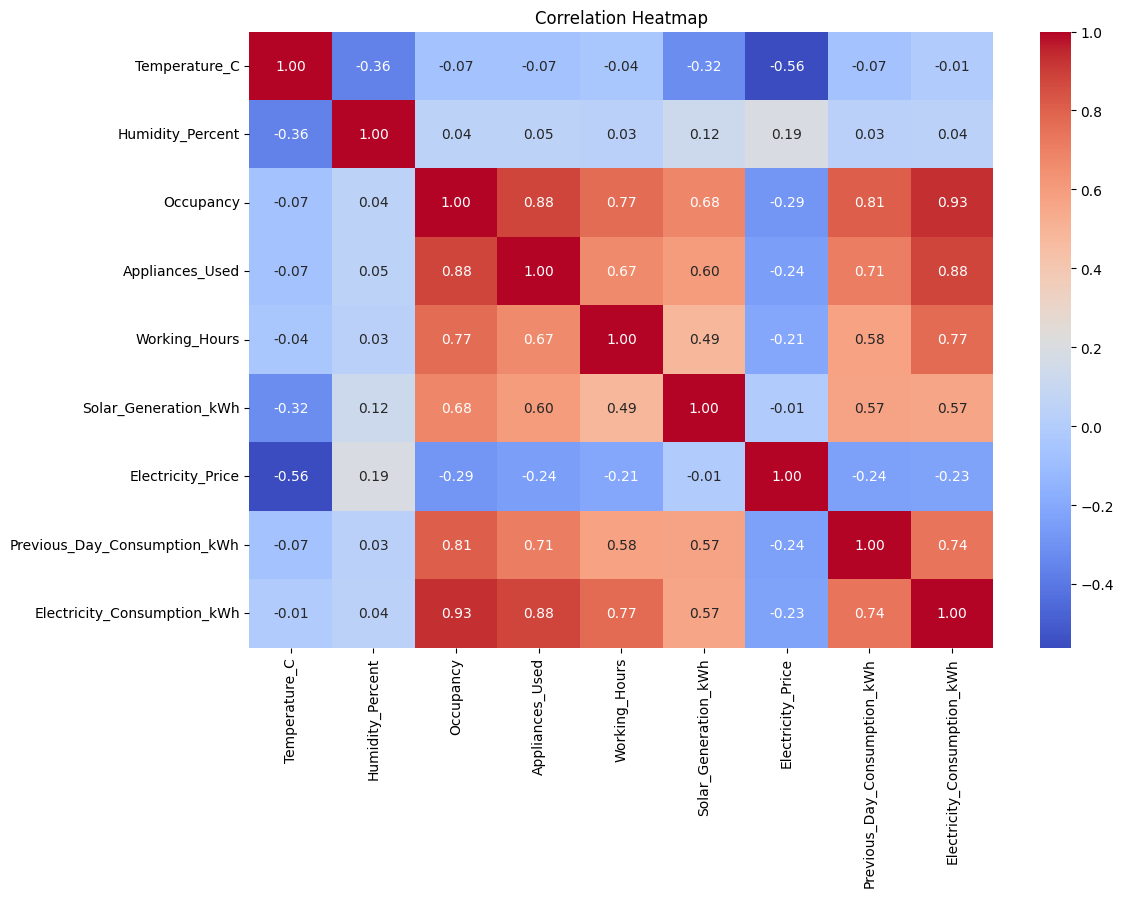

In [7]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
X = df.drop("Electricity_Consumption_kWh", axis=1)

y = df["Electricity_Consumption_kWh"]

In [9]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Temperature_C', 'Humidity_Percent', 'Occupancy', 'Appliances_Used',
       'Working_Hours', 'Solar_Generation_kWh', 'Electricity_Price',
       'Previous_Day_Consumption_kWh'],
      dtype='object')

Target:
Electricity_Consumption_kWh


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 8)
X_test: (2000, 8)
y_train: (8000,)
y_test: (2000,)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test_scaled
)

In [13]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression")
print("----------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
----------------------
MAE : 9.900139370518241
MSE : 152.27040891834727
RMSE: 12.339789662646089
R²  : 0.9074553397335587


In [14]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(
    X_test
)

In [15]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Regression")
print("----------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Regression
----------------------
MAE : 11.980973302054398
MSE : 234.42674341225305
RMSE: 15.31100073190035
R²  : 0.8575235761132767


In [16]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [17]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Regression")
print("----------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression
----------------------
MAE : 10.372750250000001
MSE : 169.58621313476505
RMSE: 13.02252714087266
R²  : 0.8969313959822295


In [18]:
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

In [19]:
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

mse_knn = mean_squared_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(mse_knn)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print("KNN Regression")
print("----------------------")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R²  :", r2_knn)

KNN Regression
----------------------
MAE : 11.634828
MSE : 214.68847693600003
RMSE: 14.65225159953241
R²  : 0.8695198081997936


In [20]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

y_pred_gb = gb_model.predict(
    X_test
)

In [21]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Regression")
print("----------------------")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Regression
----------------------
MAE : 9.91689159486489
MSE : 154.8656563526215
RMSE: 12.444503057680588
R²  : 0.9058780385768971


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf,
        mae_knn,
        mae_gb
    ],

    "MSE": [
        mse_linear,
        mse_dt,
        mse_rf,
        mse_knn,
        mse_gb
    ],

    "RMSE": [
        rmse_linear,
        rmse_dt,
        rmse_rf,
        rmse_knn,
        rmse_gb
    ],

    "R2 Score": [
        r2_linear,
        r2_dt,
        r2_rf,
        r2_knn,
        r2_gb
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.900139,152.270409,12.339790,0.907455
1,Decision Tree,11.980973,234.426743,15.311001,0.857524
2,Random Forest,10.372750,169.586213,13.022527,0.896931
3,KNN,11.634828,214.688477,14.652252,0.869520
4,Gradient Boosting,9.916892,154.865656,12.444503,0.905878


In [23]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.900139,152.270409,12.339790,0.907455
4,Gradient Boosting,9.916892,154.865656,12.444503,0.905878
2,Random Forest,10.372750,169.586213,13.022527,0.896931
3,KNN,11.634828,214.688477,14.652252,0.869520
1,Decision Tree,11.980973,234.426743,15.311001,0.857524


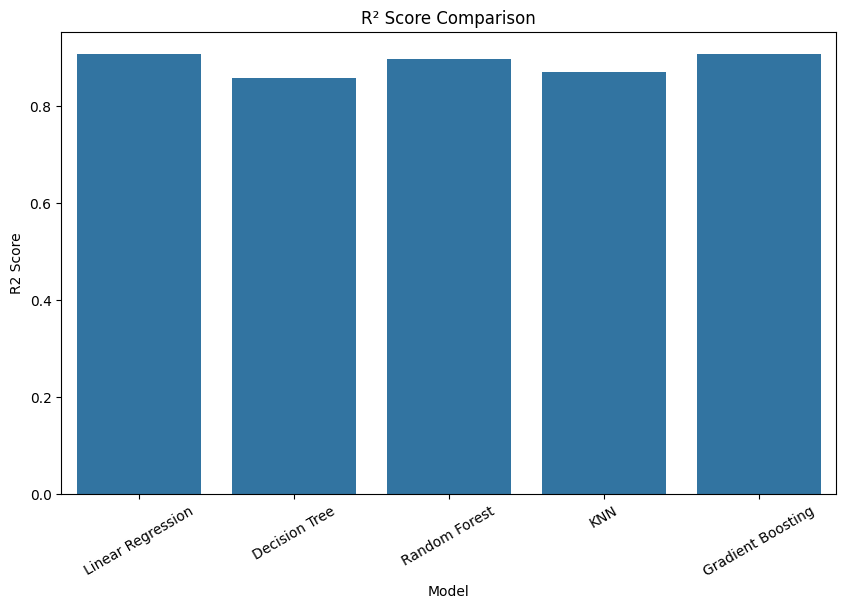

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison")
plt.xticks(rotation=30)
plt.show()

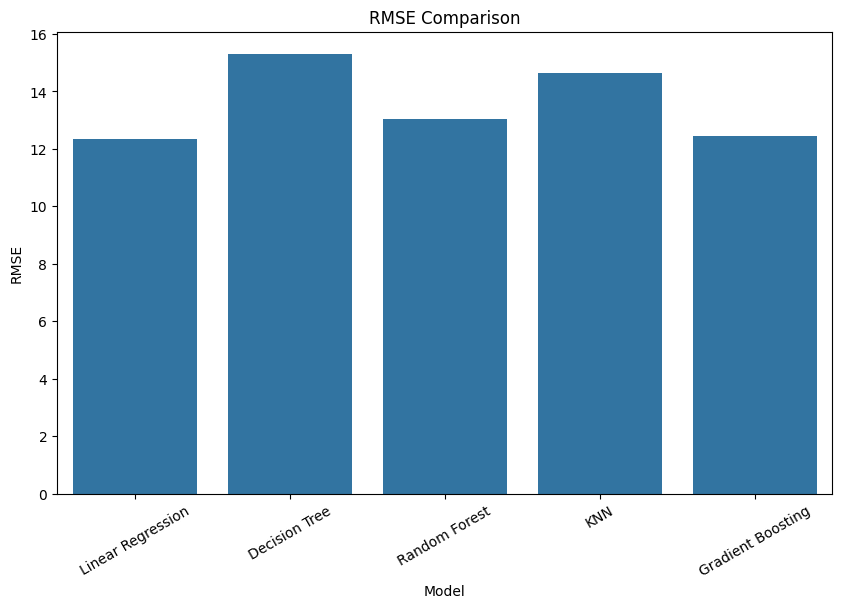

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison")
plt.xticks(rotation=30)
plt.show()

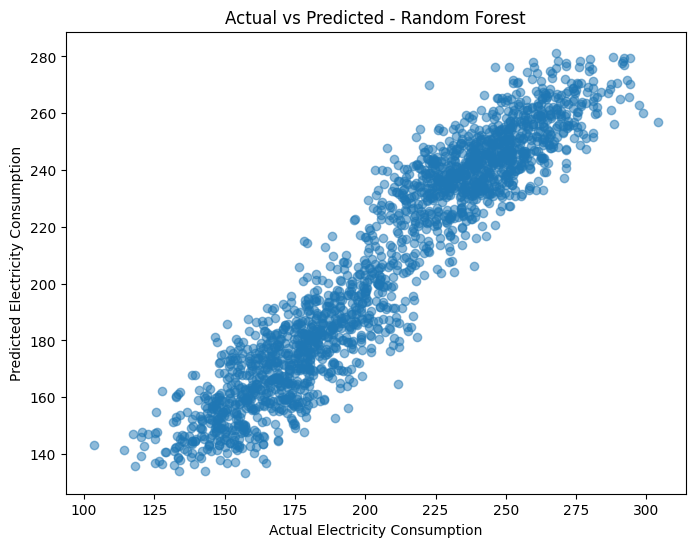

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Electricity Consumption")
plt.ylabel("Predicted Electricity Consumption")

plt.title(
    "Actual vs Predicted - Random Forest"
)

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Occupancy,0.864625
3,Appliances_Used,0.031575
0,Temperature_C,0.023064
6,Electricity_Price,0.020050
1,Humidity_Percent,0.016230
7,Previous_Day_Consumption_kWh,0.016208
5,Solar_Generation_kWh,0.015850
4,Working_Hours,0.012398


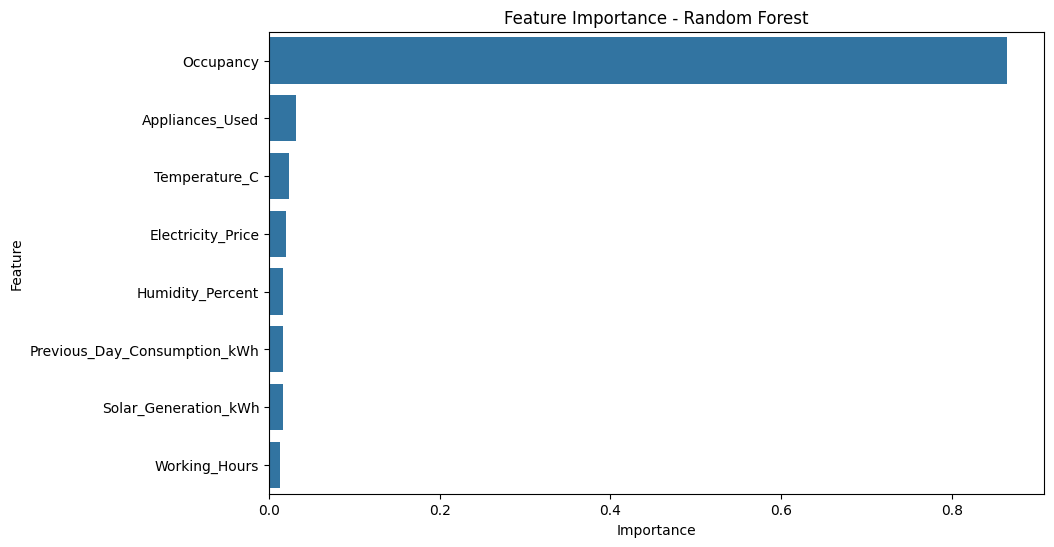

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

In [29]:
new_data = pd.DataFrame({
    "Temperature_C": [30],
    "Humidity_Percent": [70],
    "Occupancy": [40],
    "Appliances_Used": [7],
    "Working_Hours": [8],
    "Solar_Generation_kWh": [10],
    "Electricity_Price": [7],
    "Previous_Day_Consumption_kWh": [180]
})

In [30]:
prediction = rf_model.predict(new_data)

print(
    "Predicted Electricity Consumption:",
    prediction[0],
    "kWh"
)

Predicted Electricity Consumption: 222.52619999999996 kWh


In [33]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 69.5 MB/s eta 0:00:00


In [36]:
import streamlit as st


In [46]:
# 1. Install dependencies & download cloudflared binary
!pip install -q streamlit scikit-learn pandas joblib
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# 2. Write the enhanced Streamlit app to app.py
app_code = """import streamlit as st
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Page Setup
st.set_page_config(
    page_title="Electricity Consumption Predictor",
    page_icon="⚡",
    layout="wide"
)

# Custom CSS for styling
st.markdown(\"\"\"
    <style>
        .stButton>button {
            width: 100%;
            background-color: #ff4b4b;
            color: white;
            font-size: 18px;
            font-weight: bold;
            border-radius: 8px;
            height: 50px;
        }
        .stButton>button:hover {
            background-color: #e03e3e;
            color: white;
        }
    </style>
\"\"\", unsafe_allow_html=True)

st.title("⚡ Smart Electricity Consumption Predictor")
st.markdown("##### Optimize energy planning using machine learning based on environmental and operational parameters.")
st.write("---")

# Load and Train Model cached efficiently
@st.cache_resource
def load_and_train_model():
    df = pd.read_csv('Electricity_Consumption_Regression.csv')
    if 'Date' in df.columns:
        df = df.drop('Date', axis=1)

    X = df.drop("Electricity_Consumption_kWh", axis=1)
    y = df["Electricity_Consumption_kWh"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    return model, scaler, X.columns

model, scaler, feature_names = load_and_train_model()

st.subheader("🎛️ Input Operational & Environmental Parameters")

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown("##### 🌤️ Weather Conditions")
    temperature = st.number_input("Temperature (°C)", min_value=18.0, max_value=40.0, value=28.0, step=0.5)
    humidity = st.number_input("Humidity (%)", min_value=40.0, max_value=95.0, value=72.0, step=0.5)
    solar_gen = st.number_input("Solar Generation (kWh)", min_value=0.0, max_value=20.0, value=5.0, step=0.1)

with col2:
    st.markdown("##### 🏢 Facility Usage")
    occupancy = st.number_input("Building Occupancy", min_value=0, max_value=70, value=30, step=1)
    appliances = st.number_input("Appliances Used", min_value=1, max_value=15, value=5, step=1)
    working_hours = st.number_input("Working Hours", min_value=0.0, max_value=12.0, value=8.0, step=0.5)

with col3:
    st.markdown("##### 💰 Economics & History")
    elec_price = st.number_input("Electricity Price", min_value=4.0, max_value=9.0, value=6.5, step=0.1)
    prev_consumption = st.number_input("Previous Day Consumption (kWh)", min_value=100.0, max_value=310.0, value=200.0, step=1.0)

st.write("")
st.write("")

# Prediction Action Area
if st.button("🔮 Calculate Estimated Consumption"):
    input_data = np.array([[
        temperature, humidity, occupancy, appliances,
        working_hours, solar_gen, elec_price, prev_consumption
    ]])

    input_data_scaled = scaler.transform(input_data)
    prediction = model.predict(input_data_scaled)

    st.write("---")

    res_col1, res_col2, res_col3 = st.columns([1, 2, 1])
    with res_col2:
        st.success("### Predicted Electricity Consumption")
        st.metric(label="Estimated Load", value=f"{prediction[0]:.2f} kWh")
"""

with open("app.py", "w") as f:
    f.write(app_code)

# 3. Launch Streamlit in background & connect Cloudflare tunnel
import subprocess, time, re

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
tunnel = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# 4. Print the live public URL
time.sleep(5)
url = None
for _ in range(20):
    line = tunnel.stderr.readline()
    match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', line)
    if match:
        url = match.group(0)
        break
    time.sleep(0.5)

print("\n" + "=" * 55)
print(f"👉 CLICK HERE TO OPEN YOUR APP:\n{url}")
print("=" * 55)


👉 CLICK HERE TO OPEN YOUR APP:
https://headers-ears-convicted-mechanical.trycloudflare.com
